In [1]:
import pandas as pd
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Draw

In [2]:
mmpbsa_df = pd.read_csv("../mmpbsa.csv")
mmpbsa_df["id"] = mmpbsa_df["name"].str.removeprefix("ligand_")

dock_df = pd.read_csv("../docking/results.csv", names=["id", "smiles", "docking_score"])
similarity_df = pd.read_csv(
    "../screening/similarity_scores.csv", names=["smiles", "similarity"]
)
similarity_df["id"] = similarity_df["smiles"].apply(lambda x: x.split("\t")[1])
similarity_df["smiles"] = similarity_df["smiles"].apply(lambda x: x.split("\t")[0])
df = similarity_df.merge(dock_df, left_on="smiles", right_on="smiles")
df = df.drop("id_x", axis=1).rename(columns={"id_y": "id"})

df = df.merge(mmpbsa_df, left_on="id", right_on="id")

In [3]:
mol_df = df[["id", "smiles"]].drop_duplicates()
mol_df["mols"] = mol_df["smiles"].map(Chem.MolFromSmiles)

In [4]:
subset = df[["id", "docking_score", "similarity", "dg_ie_pb", "dg_ie_gb", "dg_c2_pb", "dg_c2_gb", "dg_en_pb", "dg_en_gb"]]
avg_values = subset.groupby("id").mean()
avg_values_with_mols = avg_values.merge(mol_df, on="id", how="inner")  # Keep molecules

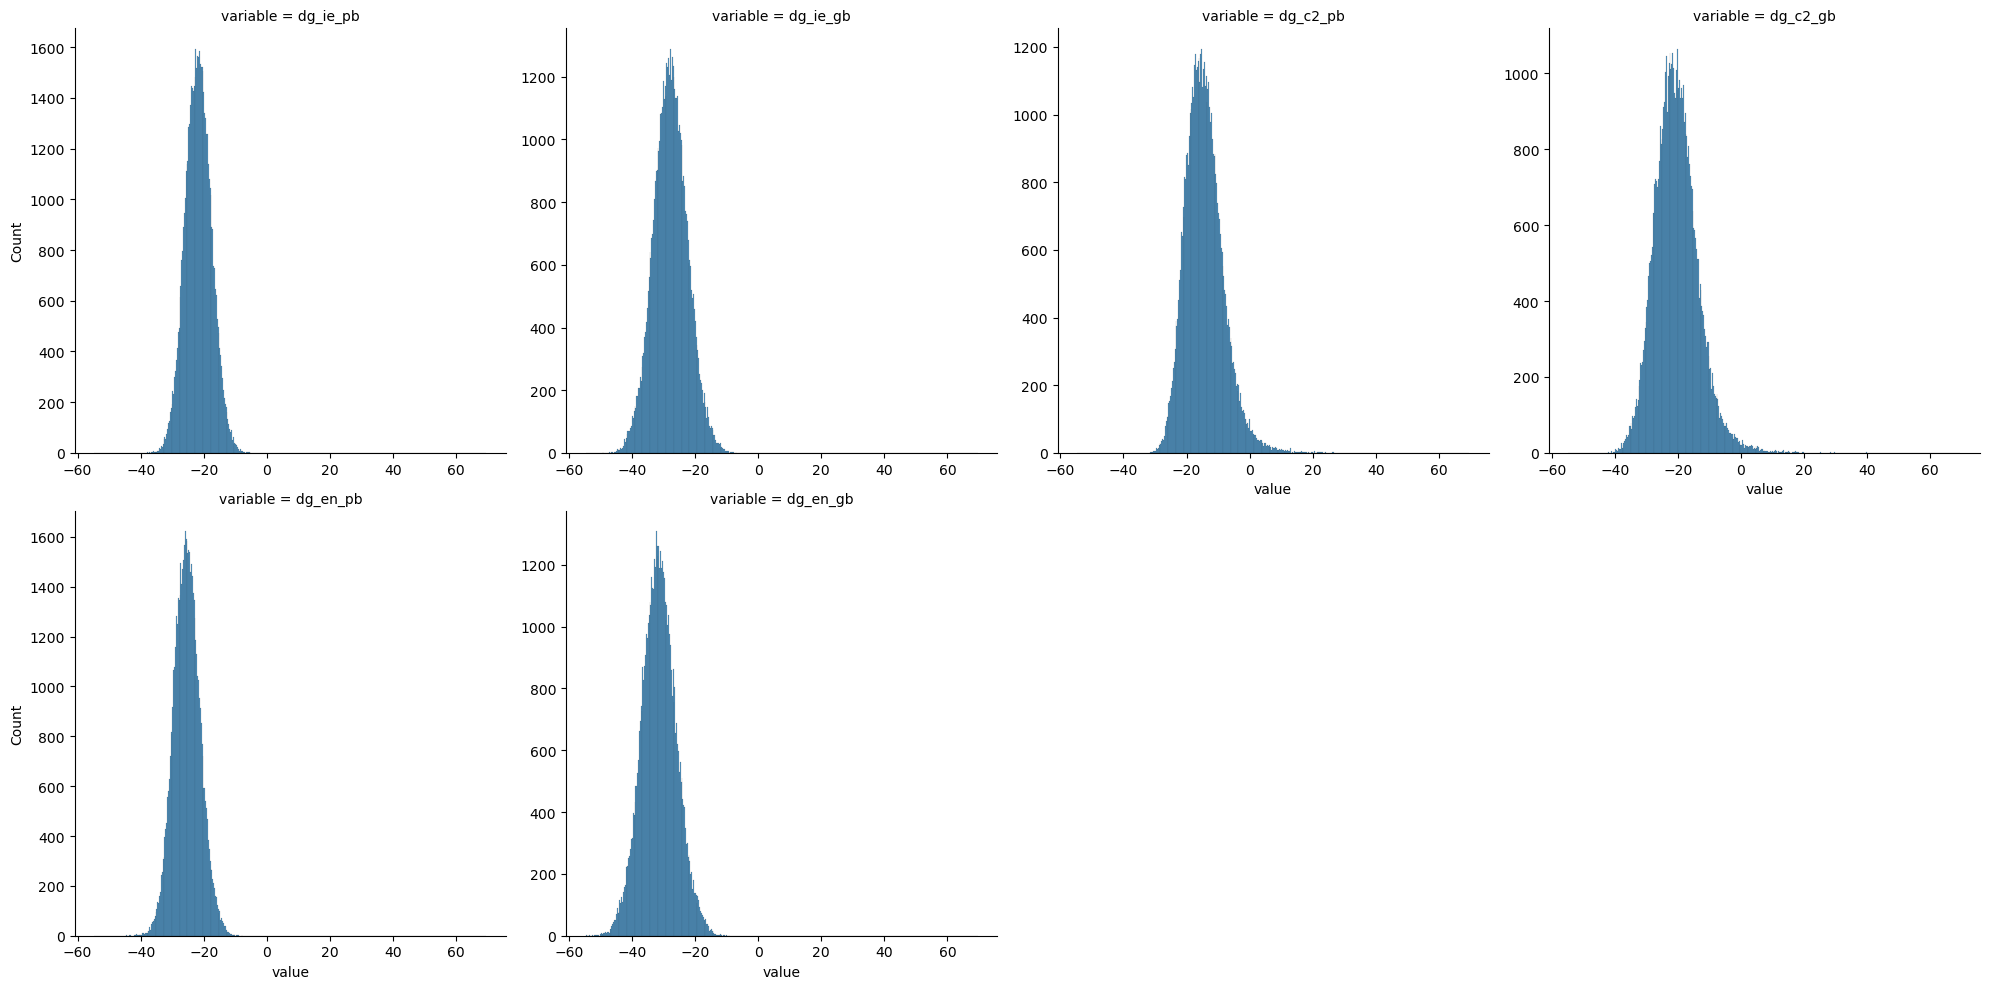

In [5]:
long_format = avg_values.reset_index().melt(id_vars="id")
sns.displot(long_format[~long_format["variable"].isin(["docking_score", "similarity"])],
             x="value", col="variable", col_wrap=4, facet_kws=dict(sharex=False, sharey=False))

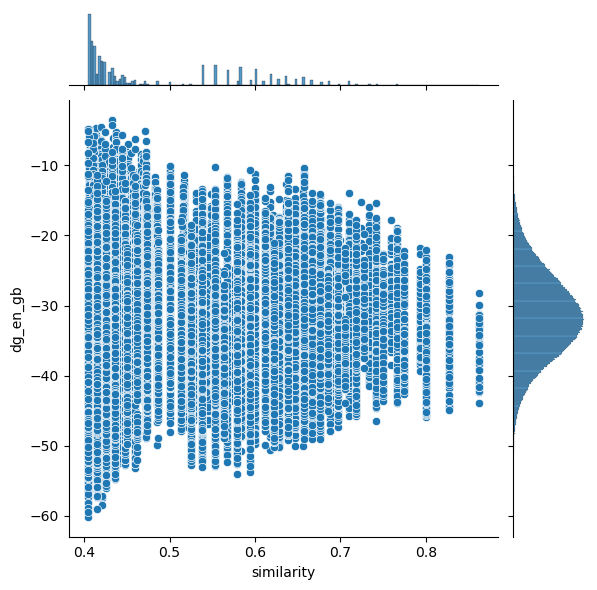

In [6]:
sns.jointplot(df, x="similarity", y="dg_en_gb")

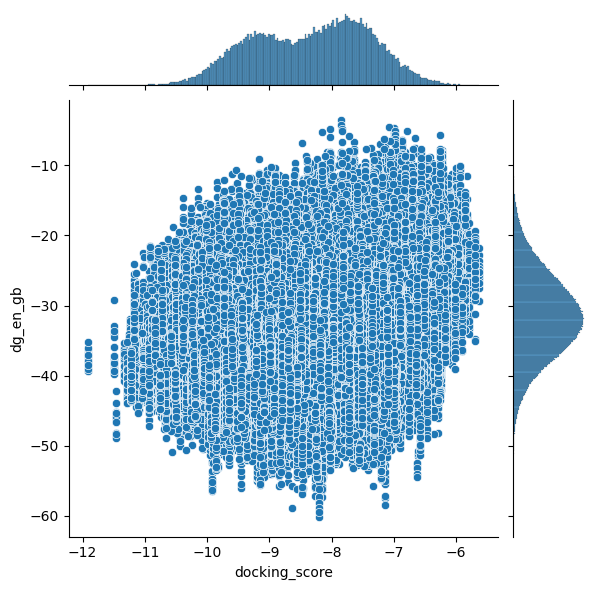

In [7]:
sns.jointplot(df, x="docking_score", y="dg_en_gb")

In [8]:
df[["dg_en_pb", "dg_en_gb", "docking_score", "similarity"]].corr()

,dg_en_pb,dg_en_gb,docking_score,similarity
dg_en_pb,1.000000,0.924433,0.333130,-0.218357
dg_en_gb,0.924433,1.000000,0.297523,-0.193263
docking_score,0.333130,0.297523,1.000000,-0.679181
similarity,-0.218357,-0.193263,-0.679181,1.000000


In [9]:
df[["dg_en_gb", "docking_score"]].corr(method="spearman")

,dg_en_gb,docking_score
dg_en_gb,1.000000,0.291843
docking_score,0.291843,1.000000


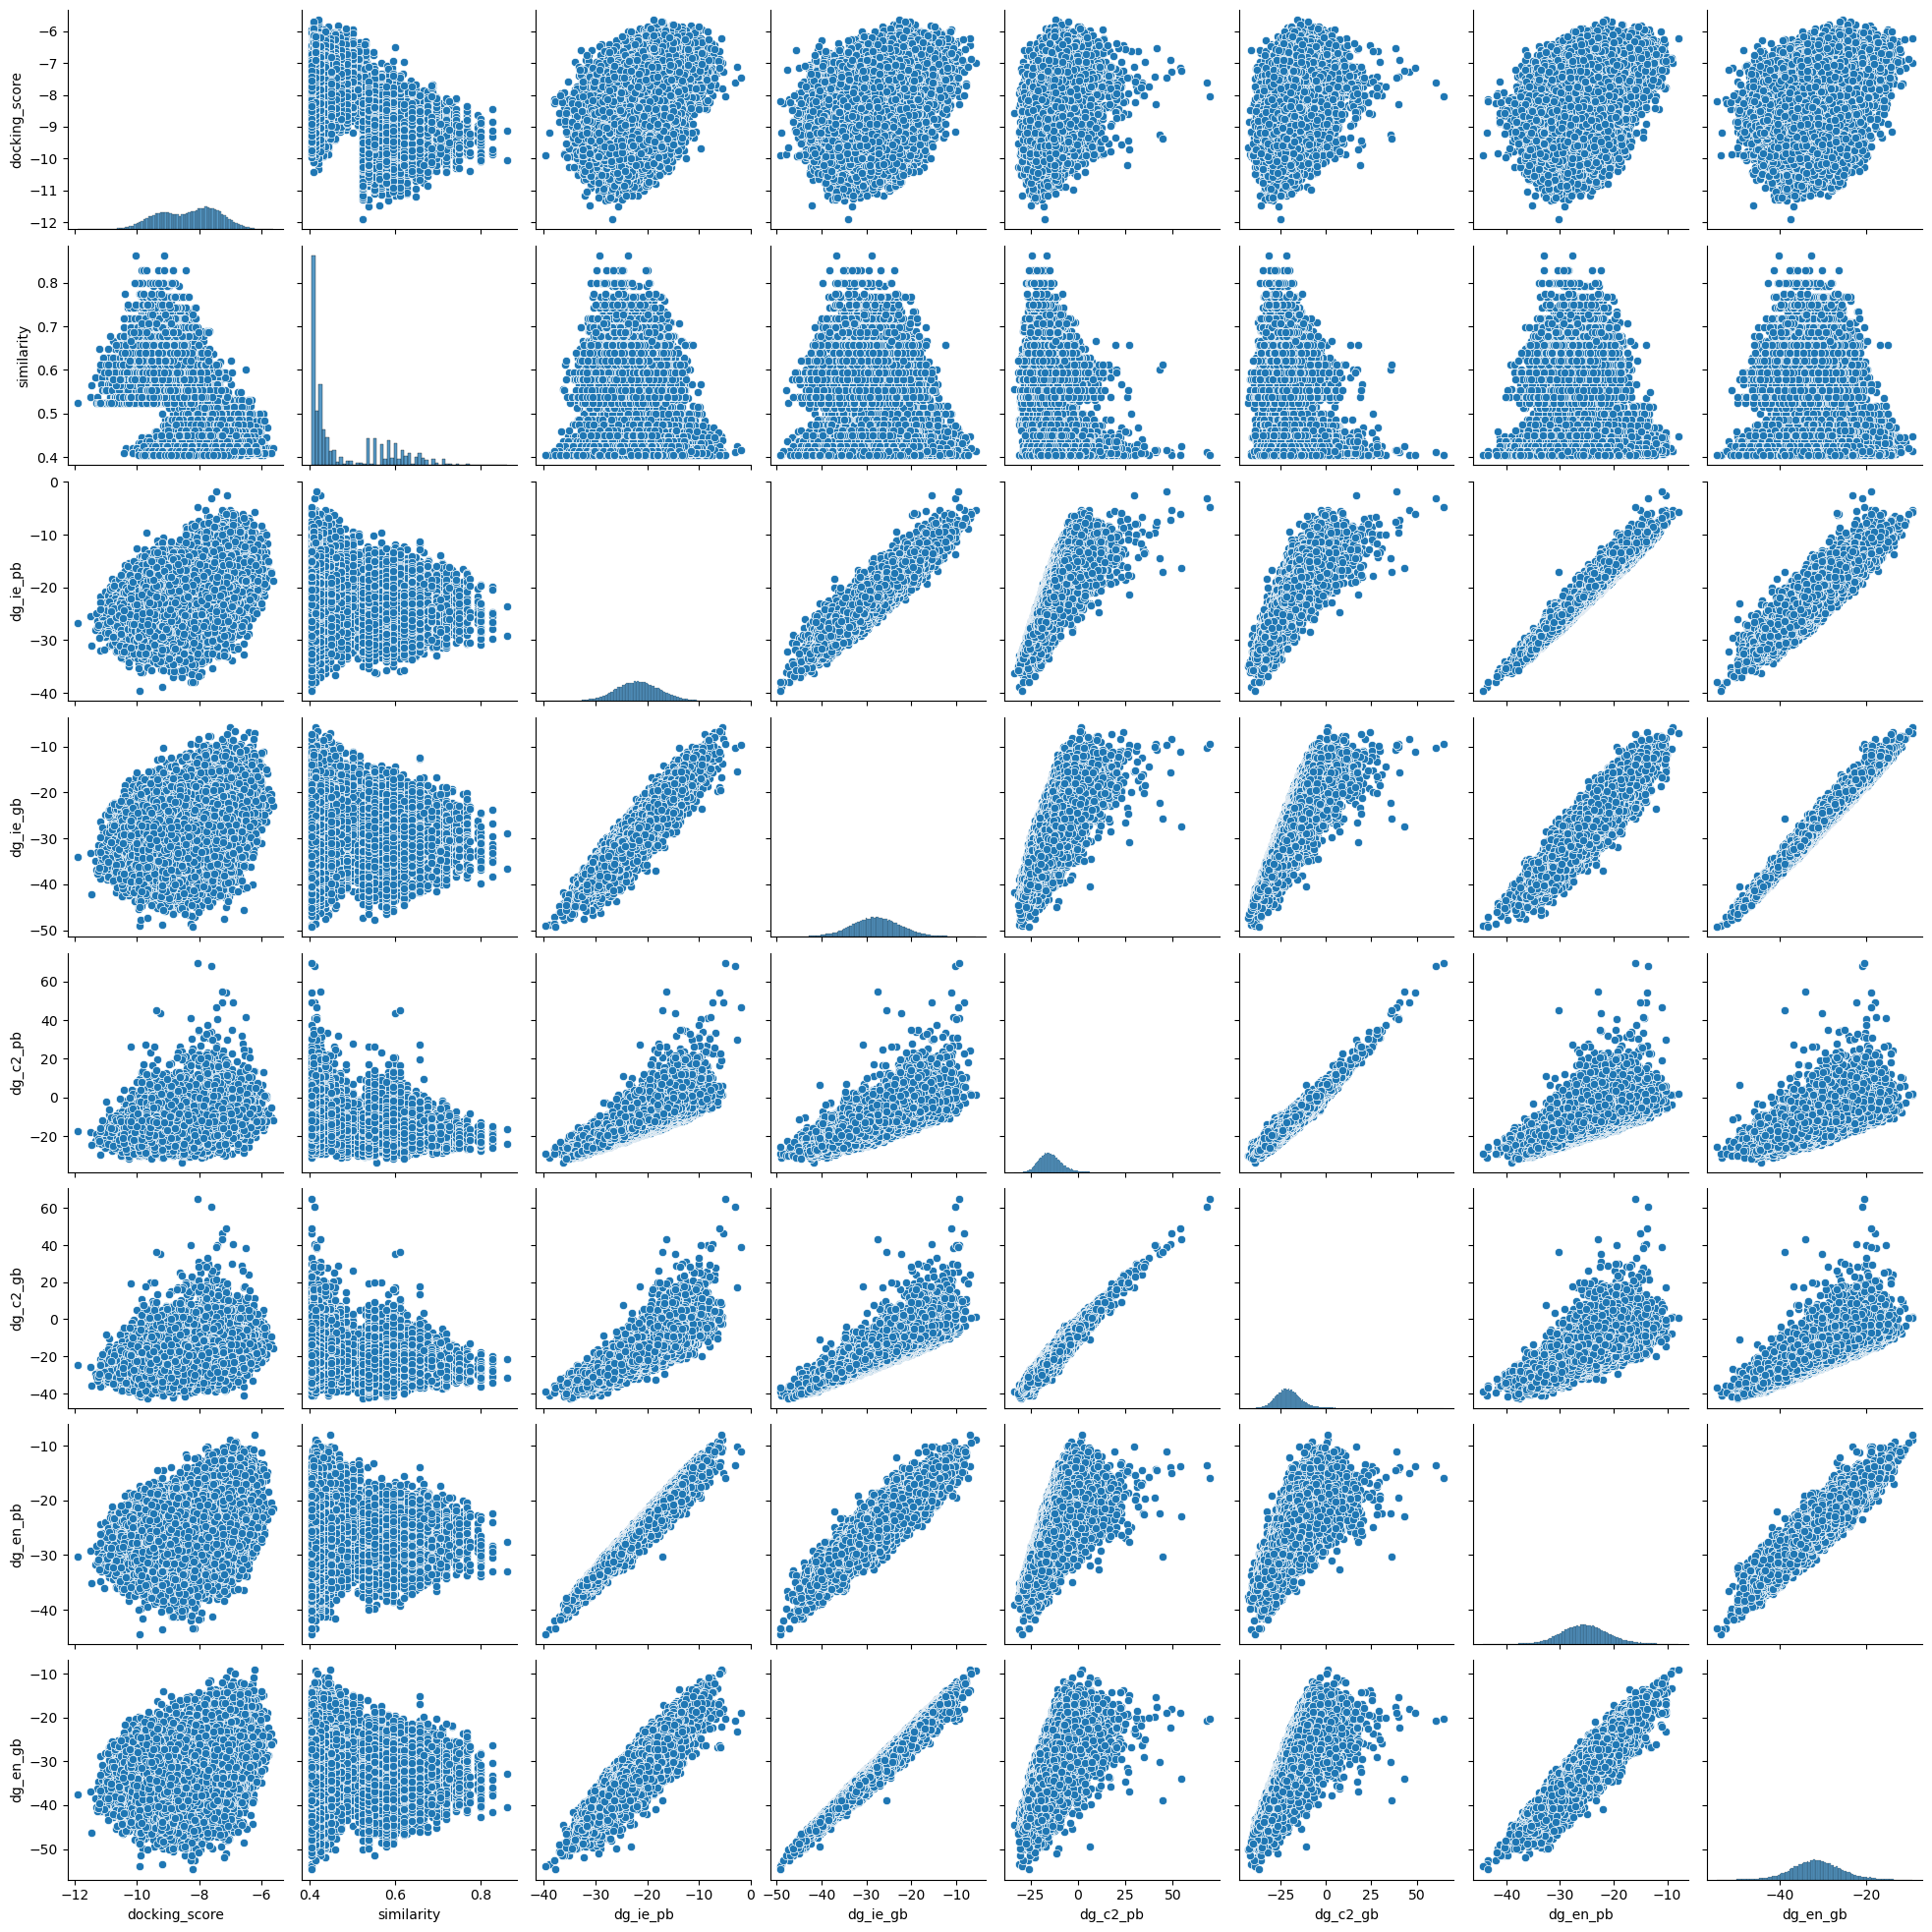

In [10]:
sns.pairplot(avg_values)

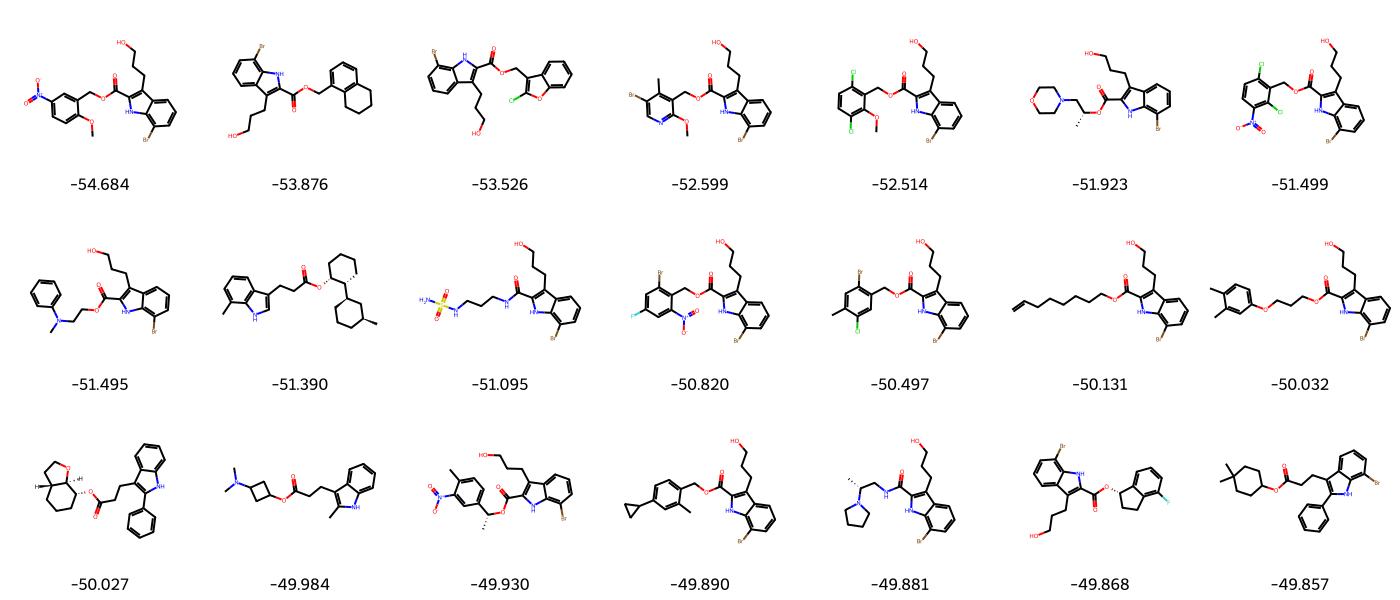

In [19]:
best_gb = avg_values_with_mols.nsmallest(21, columns="dg_en_gb")
Draw.MolsToGridImage(best_gb["mols"], molsPerRow=7,
    legends=best_gb["dg_en_gb"].apply(lambda x: f"{x:.3f}").tolist())

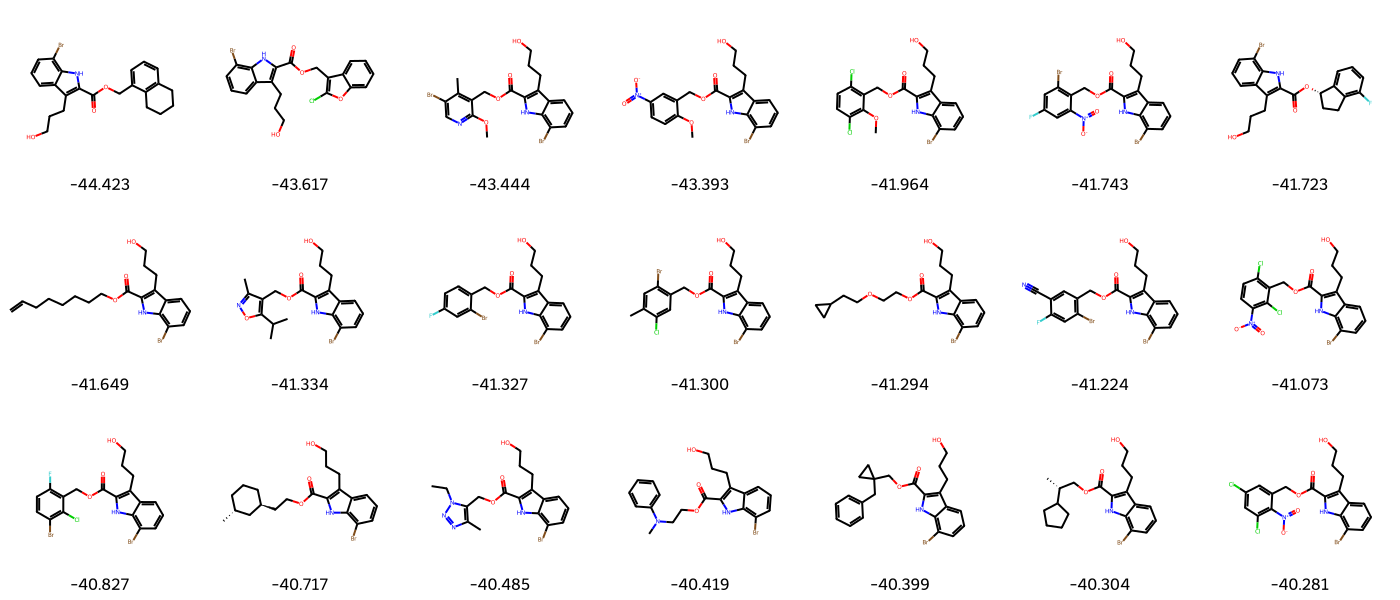

In [20]:
best_pb = avg_values_with_mols.nsmallest(21, columns="dg_en_pb")
Draw.MolsToGridImage(best_pb["mols"], molsPerRow=7,
    legends=best_pb["dg_en_pb"].apply(lambda x: f"{x:.3f}").tolist())

Let's compare the energy of the top binders in the full datasets to the subset queried using Bayesian Optimization and the experimental binders.

In [21]:
benchmark_df = pd.read_csv("../benchmark.csv")
benchmark_df["id"] = benchmark_df["name"].str.removeprefix("ligand_")
best_benchmark = benchmark_df.groupby("id")["dg_en_gb"].mean().nsmallest(21)

In [22]:
bo_df = pd.read_csv("../bo_mmpbsa_dg_en_gb.csv")
best_bo = bo_df.nsmallest(21, columns="affinity")["affinity"]

In [29]:
compare_df = pd.DataFrame()
compare_df["Benchmark"] = best_benchmark.reset_index()["dg_en_gb"]
compare_df["ZINC"] = best_gb.reset_index()["dg_en_gb"]
compare_df["Bayesian Optimization"] = best_bo.reset_index(drop=True)
compare_df = compare_df.melt(value_vars=["Benchmark", "ZINC", "Bayesian Optimization"])
compare_df["Source"] = compare_df["variable"].replace({"Benchmark": "Experimental binders", "ZINC": "Full dataset"})

Text(0.5, 1.0, 'Energy of top binders by source')

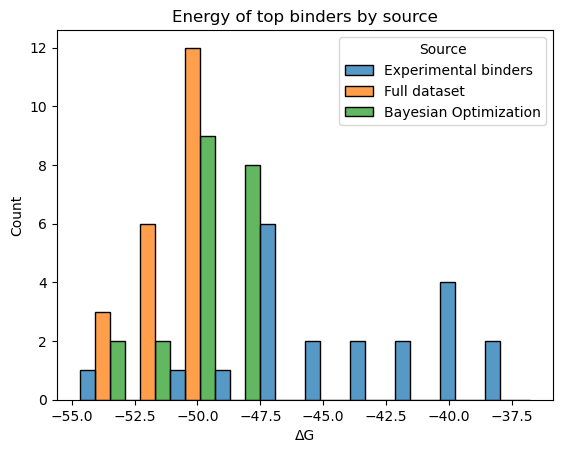

In [32]:
g = sns.histplot(compare_df, x="value", hue="Source", multiple="dodge")
g.set_xlabel("ΔG")
g.set_title("Energy of top binders by source")